In [12]:
import pandas as pd
import  nltk
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer


In [13]:
df=pd.read_csv("/content/nlp_dataset.csv")

In [5]:
print(df)

                                                Text
0  Natural Language Processing is a fascinating f...
1  It bridges the gap between humans and machines...
2  NLP techniques are widely used in applications...
3  Machine translation and speech recognition are...
4  Despite its advancements, NLP faces challenges...
5  Continuous research and innovation are improvi...
6  The potential of NLP is vast, making it essent...


In [6]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [7]:
stop_words = set(stopwords.words('english'))
print(stop_words)
lemmatizer = WordNetLemmatizer()

{'yours', 'why', 'shan', 'had', 'how', 'have', 'some', "wouldn't", 'yourselves', "i'd", 'all', 'weren', "we're", 'having', 'mustn', 'were', 'as', 'few', 'theirs', 'don', 'after', 'we', 'only', 'not', 'who', 'out', 'same', 'under', "don't", 'but', 'off', 'be', 'ain', 'him', 'i', 'where', "didn't", 'to', 'what', "won't", 're', 'such', 'any', 'because', "couldn't", "he'll", 'you', "he's", 'needn', 'more', 'that', 'ours', "she'll", 'their', 'do', "we'd", 'between', 'both', 'myself', "weren't", "it'd", 'above', 'for', 'through', "i'm", 'if', "it'll", 'm', 'an', 'doing', 'most', 'he', 'y', 'when', 'about', 'hers', 'his', 'than', 'themselves', 'nor', 'once', 'each', 'below', "hasn't", 'against', 'there', 'she', "you've", 'itself', 'are', "it's", 'here', 'didn', 'at', "should've", 't', 'no', 'those', 'did', 'with', 'ma', 's', 'of', 'couldn', "you'd", 'being', 'own', 'these', "that'll", 'does', 'ourselves', 'until', 'aren', 'isn', 'its', 'the', 'further', 'has', "he'd", 'mightn', 'and', "isn't"

In [8]:
def process_text(text):
  word_tokens= word_tokenize(text)

  filtered_tokens = [word for word in word_tokens if word_tokens if word.lower() not in stop_words]
  lemmatized_tokens=[lemmatizer.lemmatize(word.lower())for word in filtered_tokens]
  return{
      "Original_text":text,
      "word_tokens":word_tokens,
      "filtered_tokens": filtered_tokens,
      "lemmatized_tokens":lemmatized_tokens
  }

In [9]:
results = df['Text'].apply(process_text)

In [10]:
processed_df=pd.DataFrame(results.tolist())
print(processed_df.head())
processed_file_path="processed_nlp_dataset.csv"
processed_df.to_csv(processed_file_path,index=False)

                                       Original_text  \
0  Natural Language Processing is a fascinating f...   
1  It bridges the gap between humans and machines...   
2  NLP techniques are widely used in applications...   
3  Machine translation and speech recognition are...   
4  Despite its advancements, NLP faces challenges...   

                                         word_tokens  \
0  [Natural, Language, Processing, is, a, fascina...   
1  [It, bridges, the, gap, between, humans, and, ...   
2  [NLP, techniques, are, widely, used, in, appli...   
3  [Machine, translation, and, speech, recognitio...   
4  [Despite, its, advancements, ,, NLP, faces, ch...   

                                     filtered_tokens  \
0  [Natural, Language, Processing, fascinating, f...   
1  [bridges, gap, humans, machines, enabling, com...   
2  [NLP, techniques, widely, used, applications, ...   
3  [Machine, translation, speech, recognition, co...   
4  [Despite, advancements, ,, NLP, faces, chal

In [11]:
results

,Text
0,{'Original_text': 'Natural Language Processing...
1,{'Original_text': 'It bridges the gap between ...
2,{'Original_text': 'NLP techniques are widely u...
3,{'Original_text': 'Machine translation and spe...
4,"{'Original_text': 'Despite its advancements, N..."
5,{'Original_text': 'Continuous research and inn...
6,{'Original_text': 'The potential of NLP is vas...


In [14]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

In [16]:
text_data = [
    "Natural Language Processing is a fascinating field of Artificial Intelligence.",
    "It bridges the gap between humans and machines by enabling computers to understand human language.",
    "NLP techniques are widely used in applications such as chatbots and sentiment analysis.",
    "Machine translation and speech recognition are common use cases of NLP.",
    "Despite its advancements, NLP faces challenges including ambiguity in language.",
    "Continuous research and innovation are improving NLP rapidly.",
    "The potential of NLP is vast, making it essential in modern technology."
]

In [17]:
vectorizer=CountVectorizer()
bow_matrix=vectorizer.fit_transform(text_data)

In [21]:
bow_df=pd.DataFrame(bow_matrix.toarray(),columns=vectorizer.get_feature_names_out())
print("Bagnof words representation")
print(bow_df)
bow_df.to_csv("bag_of_words.csv",index=False)
print("\nBags of words saved as 'bag_of_words.csv'.")

Bagnof words representation
   advancements  ambiguity  analysis  and  applications  are  artificial  as  \
0             0          0         0    0             0    0           1   0   
1             0          0         0    1             0    0           0   0   
2             0          0         1    1             1    1           0   1   
3             0          0         0    1             0    1           0   0   
4             1          1         0    0             0    0           0   0   
5             0          0         0    1             0    1           0   0   
6             0          0         0    0             0    0           0   0   

   between  bridges  ...  techniques  technology  the  to  translation  \
0        0        0  ...           0           0    0   0            0   
1        1        1  ...           0           0    1   1            0   
2        0        0  ...           1           0    0   0            0   
3        0        0  ...           

In [24]:
print(bow_matrix)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 78 stored elements and shape (7, 60)>
  Coords	Values
  (0, 39)	1
  (0, 34)	1
  (0, 43)	1
  (0, 31)	1
  (0, 21)	1
  (0, 22)	1
  (0, 41)	1
  (0, 6)	1
  (0, 30)	1
  (1, 34)	1
  (1, 32)	1
  (1, 9)	1
  (1, 52)	1
  (1, 23)	1
  (1, 8)	1
  (1, 25)	1
  (1, 3)	1
  (1, 36)	1
  (1, 10)	1
  (1, 18)	1
  (1, 15)	1
  (1, 53)	1
  (1, 55)	1
  (1, 24)	1
  (2, 3)	1
  :	:
  (4, 0)	1
  (4, 20)	1
  (4, 12)	1
  (4, 28)	1
  (4, 1)	1
  (5, 3)	1
  (5, 40)	1
  (5, 5)	1
  (5, 16)	1
  (5, 46)	1
  (5, 29)	1
  (5, 26)	1
  (5, 44)	1
  (6, 31)	1
  (6, 41)	1
  (6, 32)	1
  (6, 52)	1
  (6, 40)	1
  (6, 27)	1
  (6, 42)	1
  (6, 58)	1
  (6, 37)	1
  (6, 19)	1
  (6, 38)	1
  (6, 51)	1


In [26]:
import pandas as pd
import nltk
from nltk.stem import WordNetLemmatizer,PorterStemmer
from nltk.tokenize import word_tokenize

In [27]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [29]:
file_path= "/content/nlp_dataset.csv"
data = pd.read_csv(file_path)

In [30]:
lemmatizer=WordNetLemmatizer()
stemmer=PorterStemmer()

In [31]:
def lemmatizer_text(Text):
  tokens = word_tokenize(str(Text))
  return ''.join([lemmatizer.lemmatize(word)for word in tokens])

In [32]:
def stem_text(Text):
  tokens = word_tokenize(str(Text))
  return ''.join([stemmer.stem(word)for word in tokens])

In [33]:
data['lemmatized_text']=data['Text'].apply(lemmatizer_text)
data['stemmed_text']=data['Text'].apply(stem_text)

In [34]:
output_path="lemmatized_and_stemmed_data.csv"
data.to_csv(output_path,index=False)

In [36]:
print(data[['Text','lemmatized_text','stemmed_text']])
print(f"Comparison dataset saved to{output_path}")

                                                Text  \
0  Natural Language Processing is a fascinating f...   
1  It bridges the gap between humans and machines...   
2  NLP techniques are widely used in applications...   
3  Machine translation and speech recognition are...   
4  Despite its advancements, NLP faces challenges...   
5  Continuous research and innovation are improvi...   
6  The potential of NLP is vast, making it essent...   

                                     lemmatized_text  \
0  NaturalLanguageProcessingisafascinatingfieldof...   
1  Itbridgethegapbetweenhumanandmachinebyenabling...   
2  NLPtechniquearewidelyusedinapplicationsuchacha...   
3  Machinetranslationandspeechrecognitionarecommo...   
4  Despiteitadvancement,NLPfacechallengeincluding...   
5  ContinuousresearchandinnovationareimprovingNLP...   
6  ThepotentialofNLPisvast,makingitessentialinmod...   

                                        stemmed_text  
0  naturlanguagprocessisafascinfieldofartificii

In [1]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
file_path='/content/nlp_dataset.csv'
data=pd.read_csv(file_path)

In [4]:
text_data=" ".join(data['Text'].dropna())

In [5]:
wordcloud=WordCloud(width=800,height=400,background_color='white').generate(text_data)

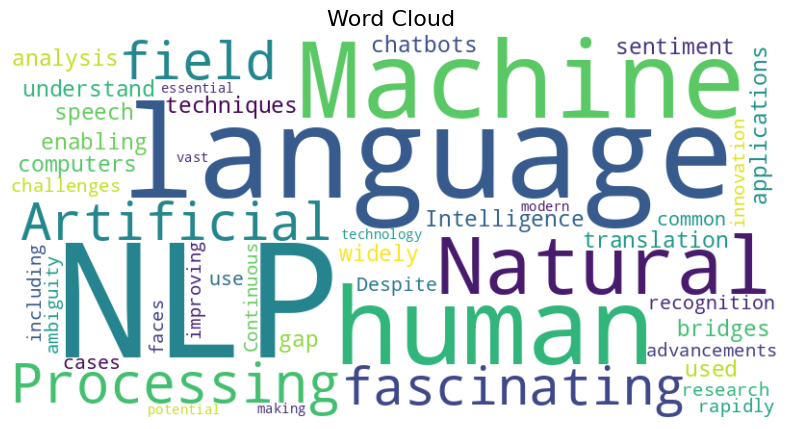

In [7]:
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud ",fontsize=16)
plt.show()